# 02 — MRMS Storm-Proxy Feasibility

## Purpose

Notebook 01 showed that the summer negative label represents **no nearby observed hail report**, not necessarily a storm without hail.

This notebook asks whether MRMS composite reflectivity can provide an independent source of evidence for storm occurrence.

Let

$$
S = \text{storm occurrence},
\qquad
H = \text{observed hail occurrence}.
$$

The long-term objective is to construct a sample frame in which storm occurrence is established independently of hail reports before assigning $H$.

This notebook is a **feasibility study**, not the final operational definition of $S$.

It tests three questions:

1. Can NOAA hail reports be aligned reliably with MRMS radar observations in space and time?
2. Do known hail reports show strong nearby radar reflectivity?
3. Do the existing summer negatives contain a mixture of radar-supported convection and weak/background cases?

A successful feasibility result motivates the storm-first construction developed in Notebook 03.

## 1. Data and pilot design

The feasibility study uses:

- the summer negative-sample table audited in Notebook 01;
- the original NOAA hail-event table for time-zone verification;
- NOAA MRMS `MergedReflectivityQCComposite_00.50` radar data.

Rather than process the full archive immediately, the pilot uses a compact hail-active episode.

The pilot is selected only to test radar alignment and sample semantics. It should not be interpreted as a representative hail climatology or as an independent validation sample.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Locate repository root
# ------------------------------------------------------------

cwd = Path.cwd()

if (cwd / "data").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "data").exists():
    REPO_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the repository data directory. "
        "Run this notebook from the repository root or notebooks/."
    )


DATA_DIR = REPO_ROOT / "data"

NEG_PATH = (
    DATA_DIR
    / "summer_pipeline"
    / "processed"
    / "valid_negative_records_all_years.csv"
)

HAIL_PATH = (
    DATA_DIR
    / "hail_records"
    / "Combined US Hail Data.csv"
)


for path in [NEG_PATH, HAIL_PATH]:
    if not path.exists():
        raise FileNotFoundError(
            f"Required local file not found: {path}\n"
            "See data/README.md for data-access instructions."
        )


# ------------------------------------------------------------
# Load summer negative table
# ------------------------------------------------------------

neg = pd.read_csv(
    NEG_PATH,
    parse_dates=["event_time"],
)


print(f"Summer negative records: {len(neg):,}")
print(
    "Parent hail events:",
    f"{neg['parent_event_id'].nunique():,}",
)

Summer negative records: 1,516,901
Parent hail events: 229,829


## 2. Select a compact hail-active pilot

The summer table is first reduced to one record per parent hail event.

To keep the feasibility study computationally small, candidate events are restricted to:

- 2022–2024;
- approximate CONUS geographic bounds.

The most hail-active hourly windows are then inspected.

The selected pilot hour is **2024-03-14 16:00 in the NOAA event-time representation**. It contains 42 hail reports across several spatially separated clusters, so the full hour is not treated as one meteorological storm.

A compact Illinois/Missouri-area cluster is used for the radar-matching pilot.

In [2]:
# ------------------------------------------------------------
# One record per parent hail event
# ------------------------------------------------------------

parents = (
    neg[
        [
            "parent_event_id",
            "event_time",
            "positive_lat",
            "positive_lon",
        ]
    ]
    .drop_duplicates("parent_event_id")
    .copy()
)


# ------------------------------------------------------------
# Recent approximate-CONUS candidate pool
# ------------------------------------------------------------

pilot_pool = parents[
    parents["event_time"].dt.year.between(2022, 2024)
    & parents["positive_lat"].between(24, 50)
    & parents["positive_lon"].between(-125, -66)
].copy()


pilot_pool["hour"] = (
    pilot_pool["event_time"]
    .dt.floor("h")
)


hour_counts = (
    pilot_pool
    .groupby("hour")
    .size()
    .sort_values(ascending=False)
    .rename("hail_report_count")
)


print(
    "Parent hail events in 2022–2024 CONUS candidate pool:",
    f"{len(pilot_pool):,}",
)

print("\nMost hail-active hours:")
display(
    hour_counts
    .head(10)
    .to_frame()
)


# ------------------------------------------------------------
# Pilot hour
# ------------------------------------------------------------

PILOT_HOUR = pd.Timestamp(
    "2024-03-14 16:00:00"
)

episode = pilot_pool[
    pilot_pool["hour"] == PILOT_HOUR
].copy()


# ------------------------------------------------------------
# Compact pilot cluster
# ------------------------------------------------------------

pilot_cluster = episode[
    episode["positive_lat"].between(38.0, 40.0)
    & episode["positive_lon"].between(-91.7, -88.5)
].copy()


pilot_cluster = (
    pilot_cluster
    .sort_values("event_time")
    .reset_index(drop=True)
)


print("\nPilot-hour hail reports:", len(episode))
print("Compact-cluster hail reports:", len(pilot_cluster))

print(
    "Cluster time range:",
    pilot_cluster["event_time"].min(),
    "to",
    pilot_cluster["event_time"].max(),
)

print(
    "Latitude range:",
    pilot_cluster["positive_lat"].min(),
    "to",
    pilot_cluster["positive_lat"].max(),
)

print(
    "Longitude range:",
    pilot_cluster["positive_lon"].min(),
    "to",
    pilot_cluster["positive_lon"].max(),
)

Parent hail events in 2022–2024 CONUS candidate pool: 17,387

Most hail-active hours:


,hail_report_count
hour,
2024-03-14 16:00:00,42
2024-05-08 14:00:00,32
2024-03-14 17:00:00,31
2023-03-31 14:00:00,30
2023-04-15 14:00:00,28
2024-05-26 15:00:00,28
2023-05-07 15:00:00,28
2022-06-07 18:00:00,28
2022-04-12 17:00:00,26



Pilot-hour hail reports: 42
Compact-cluster hail reports: 16
Cluster time range: 2024-03-14 16:04:00 to 2024-03-14 16:59:00
Latitude range: 38.2056 to 39.58
Longitude range: -91.3892 to -89.1164


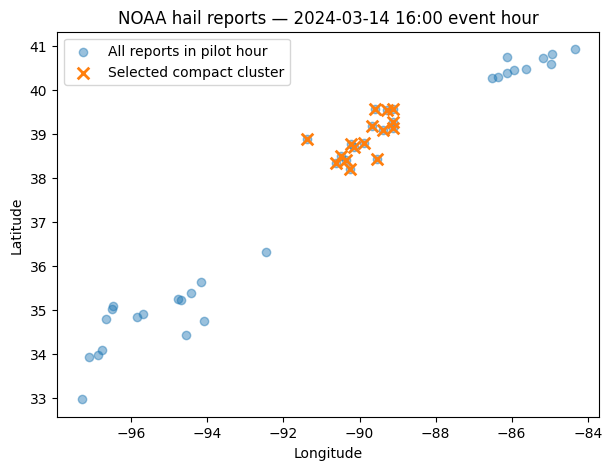

In [3]:
# ------------------------------------------------------------
# Visualize spatial structure of the pilot hour
# ------------------------------------------------------------

plt.figure(
    figsize=(7, 5)
)

plt.scatter(
    episode["positive_lon"],
    episode["positive_lat"],
    alpha=0.45,
    label="All reports in pilot hour",
)

plt.scatter(
    pilot_cluster["positive_lon"],
    pilot_cluster["positive_lat"],
    marker="x",
    s=70,
    linewidths=2,
    label="Selected compact cluster",
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(
    "NOAA hail reports — 2024-03-14 16:00 event hour"
)
plt.legend()
plt.show()

## 3. Verify event-time interpretation

Radar matching requires NOAA event times and MRMS scan times to use the same time standard.

The compact pilot events are therefore matched back to the original NOAA event table.

For all 16 pilot reports:

- the processed summer timestamp matches the original `BEGIN_DATE_TIME`;
- `CZ_TIMEZONE` is `CST-6`.

For this specific pilot, the NOAA event time is therefore converted to UTC by adding six hours.

This conversion is verified for the selected pilot and should not be generalized to other events without checking their recorded time-zone metadata.

In [4]:
# ------------------------------------------------------------
# Load original NOAA hail-event table
# ------------------------------------------------------------

raw_hail = pd.read_csv(
    HAIL_PATH,
    low_memory=False,
)

raw_hail["BEGIN_DATE_TIME"] = pd.to_datetime(
    raw_hail["BEGIN_DATE_TIME"],
    errors="coerce",
)


pilot_ids = (
    pilot_cluster["parent_event_id"]
    .astype(int)
    .unique()
)


# EVENT_ID is not assumed globally unique,
# so restrict explicitly to 2024.
pilot_raw = raw_hail[
    raw_hail["EVENT_ID"].isin(pilot_ids)
    & (
        raw_hail["BEGIN_DATE_TIME"]
        .dt.year
        == 2024
    )
][
    [
        "EVENT_ID",
        "BEGIN_DATE_TIME",
        "CZ_TIMEZONE",
        "STATE_ABBR",
        "BEGIN_LAT",
        "BEGIN_LON",
    ]
].copy()


time_check = pilot_cluster.merge(
    pilot_raw,
    left_on="parent_event_id",
    right_on="EVENT_ID",
    how="left",
    validate="one_to_one",
)


time_check["time_match"] = (
    time_check["event_time"]
    == time_check["BEGIN_DATE_TIME"]
)


timezone_summary = pd.DataFrame(
    {
        "pilot_reports": [len(time_check)],
        "matching_raw_times": [
            int(time_check["time_match"].sum())
        ],
        "CST-6_records": [
            int(
                (
                    time_check["CZ_TIMEZONE"]
                    == "CST-6"
                ).sum()
            )
        ],
    }
)


display(timezone_summary)


assert time_check["time_match"].all()
assert (
    time_check["CZ_TIMEZONE"]
    == "CST-6"
).all()


# ------------------------------------------------------------
# Convert this verified pilot to UTC
# ------------------------------------------------------------

pilot_cluster["event_time_utc"] = (
    pilot_cluster["event_time"]
    + pd.Timedelta(hours=6)
)


print(
    "Pilot UTC range:",
    pilot_cluster["event_time_utc"].min(),
    "to",
    pilot_cluster["event_time_utc"].max(),
)

,pilot_reports,matching_raw_times,CST-6_records
0,16,16,16


Pilot UTC range: 2024-03-14 22:04:00 to 2024-03-14 22:59:00


## 4. MRMS archive availability

For each hail report, the feasibility study examines radar scans within

$$
\pm 10\text{ minutes}
$$

of the verified event time.

Across the 16 pilot reports, the union of these matching windows spans approximately 75 minutes.

The MRMS public archive is queried for:

`MergedReflectivityQCComposite_00.50`

on 2024-03-14.

The goal here is only to establish that the pilot interval has sufficiently dense temporal coverage for event-level radar matching.

In [5]:
import requests
import xml.etree.ElementTree as ET


# ------------------------------------------------------------
# Matching window
# ------------------------------------------------------------

MATCH_HALF_WINDOW = pd.Timedelta(
    minutes=10
)


radar_start = (
    pilot_cluster["event_time_utc"].min()
    - MATCH_HALF_WINDOW
)

radar_end = (
    pilot_cluster["event_time_utc"].max()
    + MATCH_HALF_WINDOW
)


print(
    "Required radar interval:",
    radar_start,
    "to",
    radar_end,
)


# ------------------------------------------------------------
# Query public MRMS S3 archive
# ------------------------------------------------------------

BUCKET_URL = (
    "https://noaa-mrms-pds.s3.amazonaws.com"
)

MRMS_PRODUCT = (
    "MergedReflectivityQCComposite_00.50"
)

DATE_STR = "20240314"

prefix = (
    f"CONUS/{MRMS_PRODUCT}/{DATE_STR}/"
)


response = requests.get(
    BUCKET_URL,
    params={
        "list-type": "2",
        "prefix": prefix,
    },
    timeout=30,
)

response.raise_for_status()


root = ET.fromstring(
    response.content
)

namespace = {
    "s3":
    "http://s3.amazonaws.com/doc/2006-03-01/"
}


keys = [
    item.find(
        "s3:Key",
        namespace,
    ).text
    for item
    in root.findall(
        "s3:Contents",
        namespace,
    )
]


records = []

for key in keys:

    filename = (
        key
        .split("/")[-1]
    )

    timestamp_text = (
        filename
        .replace(
            "MRMS_MergedReflectivityQCComposite_00.50_",
            "",
        )
        .replace(
            ".grib2.gz",
            "",
        )
    )

    radar_time = pd.to_datetime(
        timestamp_text,
        format="%Y%m%d-%H%M%S",
        errors="coerce",
    )

    records.append(
        {
            "key": key,
            "filename": filename,
            "radar_time_utc": radar_time,
        }
    )


radar_files = pd.DataFrame(
    records
)


pilot_radar_files = (
    radar_files[
        radar_files["radar_time_utc"]
        .between(
            radar_start,
            radar_end,
        )
    ]
    .sort_values(
        "radar_time_utc"
    )
    .reset_index(
        drop=True
    )
)


pilot_radar_files["time_gap_min"] = (
    pilot_radar_files[
        "radar_time_utc"
    ]
    .diff()
    .dt.total_seconds()
    / 60
)


archive_summary = pd.Series(
    {
        "daily_files":
            len(radar_files),

        "pilot_interval_files":
            len(pilot_radar_files),

        "median_gap_minutes":
            pilot_radar_files[
                "time_gap_min"
            ].median(),

        "maximum_gap_minutes":
            pilot_radar_files[
                "time_gap_min"
            ].max(),

        "first_scan":
            pilot_radar_files[
                "radar_time_utc"
            ].min(),

        "last_scan":
            pilot_radar_files[
                "radar_time_utc"
            ].max(),
    },
    name="value",
).to_frame()


display(archive_summary)

Required radar interval: 2024-03-14 21:54:00 to 2024-03-14 23:09:00


,value
daily_files,719
pilot_interval_files,38
median_gap_minutes,2.0
maximum_gap_minutes,2.066667
first_scan,2024-03-14 21:54:42
last_scan,2024-03-14 23:08:40


### Archive check

The pilot interval contains 38 MRMS scans with approximately two-minute spacing and no substantial temporal gap.

This is sufficient for the event-centered feasibility analysis below.

The next step downloads only these pilot scans. Raw MRMS files remain local and are excluded from version control.

In [6]:
# ------------------------------------------------------------
# Download pilot MRMS scans if missing locally
# ------------------------------------------------------------

RADAR_DIR = (
    DATA_DIR
    / "mrms"
    / "pilot_20240314"
)

RADAR_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


downloaded = 0
already_present = 0


for _, row in pilot_radar_files.iterrows():

    save_path = (
        RADAR_DIR
        / row["filename"]
    )

    if save_path.exists():
        already_present += 1
        continue

    url = (
        f"{BUCKET_URL}/{row['key']}"
    )

    response = requests.get(
        url,
        stream=True,
        timeout=60,
    )

    response.raise_for_status()

    with open(
        save_path,
        "wb",
    ) as f:

        for chunk in response.iter_content(
            chunk_size=1024 * 1024
        ):

            if chunk:
                f.write(chunk)

    downloaded += 1


print(
    f"Downloaded now: {downloaded}"
)

print(
    f"Already present: {already_present}"
)

print(
    f"Total local pilot scans: "
    f"{len(list(RADAR_DIR.glob('*.grib2.gz')))}"
)

Downloaded now: 0
Already present: 38
Total local pilot scans: 38


## 5. Decode and validate MRMS reflectivity

Before extracting radar evidence, the raw MRMS values require one important semantic check.

MRMS reflectivity files can contain negative sentinel values that do not represent physical reflectivity. In this feasibility notebook:

- `-99` is treated as unavailable reflectivity;
- `-999` is also treated as unavailable;
- neither sentinel is interpreted as 0 dBZ or as evidence of no storm.

This distinction matters because a missing radar value is not equivalent to a weak or absent radar echo.

The pilot extraction therefore uses only finite reflectivity values after these sentinel values are removed.

A later notebook treats radar-coverage and valid-data semantics more explicitly. Here the objective is narrower: avoid interpreting unavailable values as meteorological evidence.

In [7]:
import gzip
import shutil

import xarray as xr


# ------------------------------------------------------------
# Event-centered radar extraction settings
# ------------------------------------------------------------

TIME_HALF_WINDOW_MIN = 10
SPATIAL_RADII_KM = [5, 10, 20]

EARTH_RADIUS_KM = 6371.0


# ------------------------------------------------------------
# File helper
# ------------------------------------------------------------

def ensure_grib2(gz_path):
    """
    Decompress a .grib2.gz file if the corresponding
    .grib2 file does not already exist.
    """
    grib_path = gz_path.with_suffix("")

    if not grib_path.exists():

        with gzip.open(
            gz_path,
            "rb",
        ) as f_in:

            with open(
                grib_path,
                "wb",
            ) as f_out:

                shutil.copyfileobj(
                    f_in,
                    f_out,
                )

    return grib_path


# ------------------------------------------------------------
# Distance helper
# ------------------------------------------------------------

def haversine_distance_grid(
    latitudes,
    longitudes,
    lat0,
    lon0,
):
    """
    Great-circle distance from each radar grid point
    to one event location.

    Inputs: degrees
    Output: km
    """

    lat2d, lon2d = np.meshgrid(
        latitudes,
        longitudes,
        indexing="ij",
    )

    phi = np.radians(
        lat2d
    )

    phi0 = np.radians(
        lat0
    )

    dphi = np.radians(
        lat2d - lat0
    )

    dlambda = np.radians(
        lon2d - lon0
    )

    a = (
        np.sin(
            dphi / 2
        ) ** 2
        +
        np.cos(phi)
        * np.cos(phi0)
        * np.sin(
            dlambda / 2
        ) ** 2
    )

    a = np.clip(
        a,
        0,
        1,
    )

    c = (
        2
        * np.arctan2(
            np.sqrt(a),
            np.sqrt(1 - a),
        )
    )

    return (
        EARTH_RADIUS_KM
        * c
    )


# ------------------------------------------------------------
# Reflectivity cleaning
# ------------------------------------------------------------

def clean_reflectivity(
    radar,
):
    """
    Remove MRMS sentinel values before interpreting
    reflectivity as a meteorological observation.
    """

    return radar.where(
        (radar != -99)
        &
        (radar != -999)
    )

In [ ]:
%%capture

# ------------------------------------------------------------
# Inspect one representative MRMS scan
# ------------------------------------------------------------

target_time = pd.Timestamp(
    "2024-03-14 22:30:00"
)

sample_idx = (
    pilot_radar_files[
        "radar_time_utc"
    ]
    .sub(
        target_time
    )
    .abs()
    .idxmin()
)

sample_row = (
    pilot_radar_files
    .loc[
        sample_idx
    ]
)

sample_gz = (
    RADAR_DIR
    / sample_row[
        "filename"
    ]
)

sample_grib = ensure_grib2(
    sample_gz
)


ds_sample = xr.open_dataset(
    sample_grib,
    engine="cfgrib",
    backend_kwargs={
        "indexpath": "",
    },
)

var_name = (
    list(
        ds_sample.data_vars
    )[0]
)

raw_sample = (
    ds_sample[
        var_name
    ]
)


# ------------------------------------------------------------
# Pilot geographic domain
# ------------------------------------------------------------

pilot_domain = raw_sample.sel(
    latitude=slice(
        40.0,
        38.0,
    ),
    longitude=slice(
        (-91.7) % 360,
        (-88.5) % 360,
    ),
)


def sentinel_row(
    label,
    array,
):

    values = (
        array
        .values
    )

    valid = (
        np.isfinite(values)
        &
        (values != -99)
        &
        (values != -999)
    )

    return {
        "domain":
            label,

        "n_pixels":
            values.size,

        "fraction_minus99":
            np.mean(
                values == -99
            ),

        "fraction_minus999":
            np.mean(
                values == -999
            ),

        "valid_reflectivity_fraction":
            np.mean(
                valid
            ),

        "valid_min_dbz":
            (
                np.min(
                    values[valid]
                )
                if valid.any()
                else np.nan
            ),

        "valid_max_dbz":
            (
                np.max(
                    values[valid]
                )
                if valid.any()
                else np.nan
            ),
    }


sentinel_audit = pd.DataFrame(
    [
        sentinel_row(
            "full_scan",
            raw_sample,
        ),
        sentinel_row(
            "pilot_domain",
            pilot_domain,
        ),
    ]
)


ds_sample.close()

In [9]:
print(
    "Representative radar time:",
    sample_row[
        "radar_time_utc"
    ],
)

display(
    sentinel_audit
)

Representative radar time: 2024-03-14 22:30:39


,domain,n_pixels,fraction_minus99,fraction_minus999,valid_reflectivity_fraction,valid_min_dbz,valid_max_dbz
0,full_scan,24500000,0.594107,0.334887,0.071007,-22.0,68.5
1,pilot_domain,64000,0.125766,0.000000,0.874234,-3.5,68.5


## 6. Event-centered radar evidence

For the feasibility audit, each sample is summarized using the maximum valid composite reflectivity observed:

- within ±10 minutes of the sample time;
- within 5 km, 10 km, and 20 km of the sample location.

For radius $r$, define

$$
Z_{\max}(r)
=
\max
\left\{
Z(s,t):
d(s,s_0)\le r,\;
|t-t_0|\le10\text{ min}
\right\},
$$

using only valid reflectivity pixels.

This is intentionally a simple diagnostic summary.

It is **not** the final storm definition used later. In particular, this notebook does not yet impose the spatial-support, persistence, or coarse-grid criteria developed in Notebook 03.

In [10]:
def extract_radar_evidence(
    samples,
    id_col,
    time_col,
    lat_col,
    lon_col,
):
    """
    Extract event-centered MRMS maximum reflectivity
    within ±10 minutes and 5/10/20 km radii.
    """

    results = {}


    # --------------------------------------------------------
    # Initialize result table
    # --------------------------------------------------------

    for _, sample in samples.iterrows():

        sample_id = (
            sample[
                id_col
            ]
        )

        results[
            sample_id
        ] = {
            id_col:
                sample_id,

            time_col:
                sample[
                    time_col
                ],

            lat_col:
                sample[
                    lat_col
                ],

            lon_col:
                sample[
                    lon_col
                ],

            "n_scans_used":
                0,

            "zmax_5km":
                np.nan,

            "zmax_10km":
                np.nan,

            "zmax_20km":
                np.nan,
        }


    # --------------------------------------------------------
    # Process radar scans
    # --------------------------------------------------------

    for _, scan in (
        pilot_radar_files
        .iterrows()
    ):

        scan_time = (
            scan[
                "radar_time_utc"
            ]
        )


        relevant_samples = samples[
            (
                samples[
                    time_col
                ]
                - scan_time
            )
            .abs()
            <= pd.Timedelta(
                minutes=
                    TIME_HALF_WINDOW_MIN
            )
        ]


        if relevant_samples.empty:
            continue


        gz_path = (
            RADAR_DIR
            / scan[
                "filename"
            ]
        )

        grib_path = ensure_grib2(
            gz_path
        )


        ds_scan = xr.open_dataset(
            grib_path,
            engine="cfgrib",
            backend_kwargs={
                "indexpath": "",
            },
        )


        var_name = (
            list(
                ds_scan.data_vars
            )[0]
        )


        radar_scan = (
            clean_reflectivity(
                ds_scan[
                    var_name
                ]
            )
        )


        # ----------------------------------------------------
        # Evaluate samples relevant to this scan
        # ----------------------------------------------------

        for _, sample in (
            relevant_samples
            .iterrows()
        ):

            sample_id = (
                sample[
                    id_col
                ]
            )

            lat0 = float(
                sample[
                    lat_col
                ]
            )

            lon0 = float(
                sample[
                    lon_col
                ]
            )

            lon0_360 = (
                lon0
                % 360
            )


            # Bounding box slightly larger than 20 km
            local = radar_scan.sel(
                latitude=slice(
                    lat0 + 0.25,
                    lat0 - 0.25,
                ),
                longitude=slice(
                    lon0_360 - 0.30,
                    lon0_360 + 0.30,
                ),
            )


            if local.size == 0:
                continue


            distances = (
                haversine_distance_grid(
                    local[
                        "latitude"
                    ].values,
                    local[
                        "longitude"
                    ].values,
                    lat0,
                    lon0_360,
                )
            )


            values = (
                local.values
            )


            results[
                sample_id
            ][
                "n_scans_used"
            ] += 1


            for radius in (
                SPATIAL_RADII_KM
            ):

                valid_mask = (
                    (
                        distances
                        <= radius
                    )
                    &
                    np.isfinite(
                        values
                    )
                )


                if not valid_mask.any():
                    continue


                current_max = float(
                    np.max(
                        values[
                            valid_mask
                        ]
                    )
                )


                key = (
                    f"zmax_"
                    f"{radius}km"
                )


                old_max = (
                    results[
                        sample_id
                    ][
                        key
                    ]
                )


                if (
                    np.isnan(
                        old_max
                    )
                    or
                    current_max
                    > old_max
                ):

                    results[
                        sample_id
                    ][
                        key
                    ] = current_max


        ds_scan.close()


    return (
        pd.DataFrame(
            results.values()
        )
    )

In [ ]:
%%capture

# ------------------------------------------------------------
# Known hail-positive samples
# ------------------------------------------------------------

positive_samples = (
    pilot_cluster[
        [
            "parent_event_id",
            "event_time_utc",
            "positive_lat",
            "positive_lon",
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# Summer negatives linked to the same parent hail events
# ------------------------------------------------------------

pilot_parent_ids = (
    pilot_cluster[
        "parent_event_id"
    ]
    .astype(int)
    .unique()
)


pilot_negatives = neg[
    neg[
        "parent_event_id"
    ]
    .isin(
        pilot_parent_ids
    )
].copy()


# These 16 parent events were verified above as CST-6.
pilot_negatives[
    "event_time_utc"
] = (
    pilot_negatives[
        "event_time"
    ]
    + pd.Timedelta(
        hours=6
    )
)


# ------------------------------------------------------------
# Extract the same radar summaries for both groups
# ------------------------------------------------------------

positive_radar = (
    extract_radar_evidence(
        samples=
            positive_samples,

        id_col=
            "parent_event_id",

        time_col=
            "event_time_utc",

        lat_col=
            "positive_lat",

        lon_col=
            "positive_lon",
    )
)


negative_radar = (
    extract_radar_evidence(
        samples=
            pilot_negatives,

        id_col=
            "negative_event_id",

        time_col=
            "event_time_utc",

        lat_col=
            "negative_center_lat",

        lon_col=
            "negative_center_lon",
    )
)


positive_radar = (
    positive_radar
    .sort_values(
        "event_time_utc"
    )
    .reset_index(
        drop=True
    )
)


negative_radar = (
    negative_radar
    .sort_values(
        "event_time_utc"
    )
    .reset_index(
        drop=True
    )
)

In [12]:
Z_COLS = [
    "zmax_5km",
    "zmax_10km",
    "zmax_20km",
]


# ------------------------------------------------------------
# Basic sample counts
# ------------------------------------------------------------

print(
    "Known hail reports:",
    len(
        positive_radar
    ),
)

print(
    "Summer negatives:",
    len(
        negative_radar
    ),
)

print(
    "Negative parent events:",
    pilot_negatives[
        "parent_event_id"
    ].nunique(),
)


# ------------------------------------------------------------
# Reflectivity summaries
# ------------------------------------------------------------

positive_summary = (
    positive_radar[
        Z_COLS
    ]
    .describe()
    .T[
        [
            "count",
            "mean",
            "min",
            "50%",
            "max",
        ]
    ]
)


negative_summary = (
    negative_radar[
        Z_COLS
    ]
    .describe()
    .T[
        [
            "count",
            "mean",
            "min",
            "50%",
            "max",
        ]
    ]
)


negative_availability = pd.DataFrame(
    {
        "available_count":
            negative_radar[
                Z_COLS
            ]
            .notna()
            .sum(),

        "missing_count":
            negative_radar[
                Z_COLS
            ]
            .isna()
            .sum(),

        "missing_fraction":
            negative_radar[
                Z_COLS
            ]
            .isna()
            .mean(),
    }
)


print(
    "\nKnown hail positives:"
)

display(
    positive_summary
)


print(
    "\nSummer negatives:"
)

display(
    negative_summary
)


print(
    "\nNegative radar availability:"
)

display(
    negative_availability
)

Known hail reports: 16
Summer negatives: 67
Negative parent events: 16

Known hail positives:


,count,mean,min,50%,max
zmax_5km,16.0,64.18750,55.5,64.25,72.5
zmax_10km,16.0,65.71875,58.0,66.00,72.5
zmax_20km,16.0,66.59375,61.0,66.50,72.5



Summer negatives:


,count,mean,min,50%,max
zmax_5km,40.0,21.850000,6.5,18.75,55.0
zmax_10km,43.0,23.418605,5.5,21.50,56.0
zmax_20km,46.0,27.673913,3.0,24.00,59.5



Negative radar availability:


,available_count,missing_count,missing_fraction
zmax_5km,40,27,0.402985
zmax_10km,43,24,0.358209
zmax_20km,46,21,0.313433


### Interpretation

The radar evidence separates three concepts that were conflated by the summer `y=0` label.

**Known hail reports.**  
All 16 pilot hail reports have strong nearby radar reflectivity. Even at the smallest 5-km radius, the observed maximum reflectivity is well above weak/background levels.

**Radar-available summer negatives.**  
The summer negatives span a much broader reflectivity range. Many are weak, but some have reflectivity comparable to convective storms.

**Radar-unavailable summer negatives.**  
A substantial subset has no valid local reflectivity within the extraction neighborhood. These cases cannot be interpreted as evidence of no storm; the radar evidence is simply unavailable under this diagnostic.

Therefore,

> “no nearby NOAA hail report” is not equivalent to “non-hail storm.”

Some summer negatives appear meteorologically weak, some contain substantial convective radar signal, and some cannot be classified from the available radar values.

Any threshold fractions reported below are conditional on valid radar
evidence at the corresponding radius. Samples with unavailable local
reflectivity are excluded from those denominators.
This supports the sample-frame concern identified in Notebook 01.

In [13]:
# ------------------------------------------------------------
# Diagnostic threshold sensitivity
#
# This does NOT select the final storm threshold.
# ------------------------------------------------------------

THRESHOLDS_DBZ = [
    30,
    35,
    40,
]


rows = []


for radius in (
    SPATIAL_RADII_KM
):

    col = (
        f"zmax_"
        f"{radius}km"
    )


    for threshold in (
        THRESHOLDS_DBZ
    ):

        # ----------------------------------------------------
        # Known hail reports
        # ----------------------------------------------------

        pos_valid = (
            positive_radar[
                col
            ]
            .dropna()
        )


        rows.append(
            {
                "group":
                    "known_hail",

                "radius_km":
                    radius,

                "threshold_dbz":
                    threshold,

                "available_n":
                    len(
                        pos_valid
                    ),

                "above_threshold_n":
                    int(
                        (
                            pos_valid
                            >= threshold
                        )
                        .sum()
                    ),

                "fraction_above_threshold":
                    (
                        (
                            pos_valid
                            >= threshold
                        )
                        .mean()
                    ),
            }
        )


        # ----------------------------------------------------
        # Summer negatives
        # ----------------------------------------------------

        neg_valid = (
            negative_radar[
                col
            ]
            .dropna()
        )


        rows.append(
            {
                "group":
                    "summer_negative",

                "radius_km":
                    radius,

                "threshold_dbz":
                    threshold,

                "available_n":
                    len(
                        neg_valid
                    ),

                "above_threshold_n":
                    int(
                        (
                            neg_valid
                            >= threshold
                        )
                        .sum()
                    ),

                "fraction_above_threshold":
                    (
                        (
                            neg_valid
                            >= threshold
                        )
                        .mean()
                    ),
            }
        )


threshold_diagnostic = pd.DataFrame(
    rows
)


display(
    threshold_diagnostic
)

,group,radius_km,threshold_dbz,available_n,above_threshold_n,fraction_above_threshold
0,known_hail,5,30,16,16,1.000000
1,summer_negative,5,30,40,5,0.125000
2,known_hail,5,35,16,16,1.000000
3,summer_negative,5,35,40,5,0.125000
4,known_hail,5,40,16,16,1.000000
5,summer_negative,5,40,40,5,0.125000
6,known_hail,10,30,16,16,1.000000
7,summer_negative,10,30,43,8,0.186047
8,known_hail,10,35,16,16,1.000000
9,summer_negative,10,35,43,6,0.139535


## 7. Feasibility conclusion

This pilot establishes that MRMS composite reflectivity can be aligned with NOAA hail reports and summarized at the event level.

Three findings are important.

### 1. The radar–hail alignment is feasible

The compact pilot contains 16 known hail reports with dense MRMS temporal coverage. All 16 show strong nearby composite reflectivity within the event-centered extraction windows.

### 2. Summer negatives are meteorologically heterogeneous

The existing summer negative samples are not a homogeneous collection of non-hail storms.

They include:

- weak/background radar cases;
- cases with substantial convective reflectivity despite no nearby hail report;
- cases for which valid local radar reflectivity is unavailable.

This confirms that the summer label encodes a report-based condition rather than an independently established storm state.

### 3. Event-centered radar matching is not yet a storm-first sample frame

This notebook begins from known hail events and their associated summer negatives.

It therefore cannot by itself define the target storm population for

$$
P(H=1 \mid S=1, X).
$$

Doing so would remain hail-centered and would make the storm definition depend on the label-generating process.

The next notebook therefore reverses the construction order:

$$
\text{MRMS radar}
\rightarrow
\text{storm candidate } S
\rightarrow
\text{NOAA hail overlay } H.
$$

Storm candidates are identified without using hail reports, and hail labels are assigned only afterward.

### Scope of this notebook

The reflectivity thresholds and event-centered radii examined here are diagnostic feasibility checks.

They are not presented as a universally validated storm definition.

Notebook 03 develops the operational storm-first rule using spatial support, temporal persistence, and radar-data availability criteria.